# 国内期货趋势策略复现：module1-4

这份 notebook 的目标，是基于 `cta_lab` 现有的 `data`、`signals`、`portfolio`、`backtest`、`analysis` 组件，复现 `cta/module1_data.py`、`module2_signals.py`、`module3_backtest.py`、`module4_analysis.py` 这条国内期货趋势研究链路。

本次研究聚焦三件事：
- 用 `DataLoader.load_continuous_matrix()` 取代旧脚本里的批量连续合约构建
- 用 `signals + portfolio` 复现三尺度 TSMOM 与目标波动率定仓
- 用 `backtest + analysis` 跑出基础绩效、板块表现和危机阶段表现


## 研究设定

- 研究对象：国内期货趋势跟踪
- 价格对象：`adjust="nav", nav_output="normalized"` 的连续净值链
- 动量尺度：`22 / 66 / 260` 个交易日
- 波动率估计：`halflife=60` 的 EWM 年化波动率
- 组合目标：方向信号 + 目标波动率权重
- 后续扩展：可在此基础上替换信号、调整 universe、改定仓与回测细节


In [12]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
MARKET_DATA = ROOT.parent / "market_data"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from data.loader import DataLoader, KlineSchema, ContractSchema, InstrumentSchema
from data.sources import ParquetSource, ColumnKeyedSource
from signals.momentum import TSMOM
from portfolio.sizing.equal_risk import EqualRiskSizer
from analysis.metrics import performance_summary
from analysis.crisis.alpha import crisis_alpha_analysis
from analysis.attribution.sector import sector_performance

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)


In [4]:
MARKET_DATA = Path("/home/ubuntu/dengl/my_projects/market_data")

loader = DataLoader(
    kline_source=ParquetSource(MARKET_DATA / "kline" / "china_daily_full"),
    contract_source=ColumnKeyedSource(
        MARKET_DATA / "contracts" / "china" / "contract_info.parquet",
        filter_col="fut_code",
    ),
    calendar_source=ColumnKeyedSource(
        MARKET_DATA / "calendar" / "china_trading_calendar.parquet",
        filter_col="exchange",
    ),
    instrument_source=ColumnKeyedSource(
        MARKET_DATA / "contracts" / "china" / "contract_info.parquet",
        filter_col="fut_code",
    ),
    kline_schema=KlineSchema.tushare(),
    contract_schema=ContractSchema.tushare(),
    instrument_schema=InstrumentSchema.china_from_contracts(),
)

SECTOR_MAP = {
    "股指期货": ["IF", "IC", "IH", "IM"],
    "国债期货": ["T", "TF", "TL", "TS"],
    "有色金属": ["AL", "CU", "ZN", "NI", "SN", "PB", "AU", "AG", "BC"],
    "黑色金属": ["I", "J", "JM", "RB", "HC", "WR", "SF", "SM", "BB", "FB"],
    "能源化工": ["SC", "FU", "BU", "ZC", "LU", "BZ", "RU", "NR", "TA", "MA", "FG", "V", "L", "PP", "PG", "EB", "EG"],
    "农产品": ["A", "B", "C", "CS", "M", "P", "Y", "JD", "CF", "SR", "OI", "RM", "RS", "RI", "WH", "WT", "JR", "LR", "PM", "RR", "LH", "LG", "EC"],
}


## Step 1：批量加载连续价格矩阵

这里用 `load_continuous_matrix()` 替代旧 `module1_data.py` 里逐品种构建连续合约的流程。为了先把研究链路跑顺，可以从一个较小的 universe 开始，再逐步扩大。

In [5]:
symbols = [
    "RB", "HC", "I", "J", "JM",
    "CU", "AL", "AU", "AG",
    "M", "P", "Y", "CF", "SR",
    "TA", "MA", "PP", "SC",
    "IF", "IC", "T", "TF",
]

price_df = loader.load_continuous_matrix(
    symbols,
    start="2012-01-01",
    end="2026-03-31",
    adjust="nav",
    nav_output="normalized",
    stability_days=3,
)

price_df = price_df.dropna(how="all").sort_index()
returns_df = np.log(price_df / price_df.shift(1))

print(price_df.shape)
display(price_df.tail())
display(returns_df.tail())


(3454, 7)


,RB,HC,CU,AL,AU,AG,SC
2026-03-23,1.207365,2.167648,1.867026,1.515247,2.372431,1.860963,1.562255
2026-03-24,1.206215,2.170262,1.899996,1.521343,2.341678,1.889100,1.459023
2026-03-25,1.203914,2.169609,1.913666,1.530326,2.388309,1.967594,1.411094
2026-03-26,1.200845,2.161767,1.921507,1.523909,2.411935,1.993275,1.413422
2026-03-27,1.197010,2.154578,1.923919,1.533855,2.372765,1.923267,1.436902


,RB,HC,CU,AL,AU,AG,SC
2026-03-23,0.007013,0.005745,-0.016340,-0.011369,-0.039837,-0.045794,0.036299
2026-03-24,-0.000953,0.001205,0.017505,0.004015,-0.013047,0.015007,-0.068363
2026-03-25,-0.001910,-0.000301,0.007169,0.005887,0.019718,0.040711,-0.033402
2026-03-26,-0.002552,-0.003621,0.004089,-0.004202,0.009844,0.012967,0.001649
2026-03-27,-0.003199,-0.003331,0.001255,0.006505,-0.016373,-0.035754,0.016475


## Step 2：复现 module2 的三尺度动量 + 波动率

这里先保持与旧研究逻辑尽量接近：
- 三个尺度 `22 / 66 / 260`
- 每个尺度单独生成方向信号
- 再做等权合成
- 波动率使用 `EWM halflife=60`


In [6]:
ts_22 = price_df.apply(TSMOM(22).compute)
ts_66 = price_df.apply(TSMOM(66).compute)
ts_260 = price_df.apply(TSMOM(260).compute)

composite_signal = (ts_22 + ts_66 + ts_260) / 3.0
direction_df = np.sign(composite_signal).fillna(0.0)
vol_df = returns_df.ewm(halflife=60, min_periods=30).std() * np.sqrt(252)

display(composite_signal.tail())
display(direction_df.tail())
display(vol_df.tail())


,RB,HC,CU,AL,AU,AG,SC
2026-03-23,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,1.0
2026-03-24,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,1.0
2026-03-25,0.333333,0.333333,0.333333,1.000000,0.333333,0.333333,1.0
2026-03-26,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,1.0
2026-03-27,0.333333,0.333333,0.333333,1.000000,0.333333,0.333333,1.0


,RB,HC,CU,AL,AU,AG,SC
2026-03-23,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2026-03-24,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2026-03-25,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2026-03-26,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2026-03-27,1.0,1.0,1.0,1.0,1.0,1.0,1.0


,RB,HC,CU,AL,AU,AG,SC
2026-03-23,0.101331,0.094384,0.210072,0.183122,0.285376,0.658293,0.503560
2026-03-24,0.100760,0.093859,0.210920,0.182165,0.284648,0.654899,0.516019
2026-03-25,0.100229,0.093321,0.210021,0.181343,0.284930,0.654478,0.517051
2026-03-26,0.099742,0.092998,0.208902,0.180483,0.283735,0.650966,0.514088
2026-03-27,0.099307,0.092641,0.207703,0.179728,0.283562,0.650427,0.511566


## Step 3：定仓与回测

先用 `EqualRiskSizer` 复现旧 `module2/module3` 的“方向信号 + 波动率控制”思路。这里先得到目标权重矩阵，后面可以逐步换成更贴近旧脚本的月度调仓与执行设定。

In [7]:
sizer = EqualRiskSizer(target_vol=0.40, signal_mode="direction")
weight_df = sizer.compute(direction_df, vol_df)

strategy_ret = (weight_df.shift(1) * returns_df.fillna(0.0)).sum(axis=1)
strategy_ret = strategy_ret.dropna()
nav = np.exp(strategy_ret.cumsum())
nav = nav / nav.iloc[0]

display(weight_df.tail())
display(nav.tail())


,RB,HC,CU,AL,AU,AG,SC
2026-03-23,0.563923,0.605429,0.272015,0.312048,0.200237,0.086805,0.113478
2026-03-24,0.567121,0.608813,0.270922,0.313687,0.200749,0.087254,0.110738
2026-03-25,0.570121,0.612324,0.272082,0.315109,0.200551,0.087311,0.110517
2026-03-26,0.572909,0.614450,0.273539,0.316612,0.201395,0.087782,0.111154
2026-03-27,0.575415,0.616819,0.275119,0.317941,0.201518,0.087854,0.111702


2026-03-23    64.782962
2026-03-24    64.597872
2026-03-25    65.008362
2026-03-26    64.969693
2026-03-27    64.575793
dtype: float64

## Step 4：基础绩效与可视化

这一段先形成第一版基础策略结果，确认 `cta_lab` 已经可以替代 `module3_backtest.py` 的最小工作流。

In [8]:
summary = performance_summary(nav, strategy_ret)
summary


{'annual_return': np.float64(0.3554981263484651),
 'annual_vol': np.float64(0.22385500100066152),
 'sharpe': 2012-01-04    1.588073
 2012-01-05    1.588073
 2012-01-06    1.588073
 2012-01-09    1.588073
 2012-01-10    1.588073
                 ...   
 2026-03-23    1.692980
 2026-03-24    1.600855
 2026-03-25    1.559776
 2026-03-26    1.590731
 2026-03-27    1.615239
 Length: 3454, dtype: float64,
 'sortino': 2012-01-04    2.329062
 2012-01-05    2.329062
 2012-01-06    2.329062
 2012-01-09    2.329062
 2012-01-10    2.329062
                 ...   
 2026-03-23    2.482918
 2026-03-24    2.347807
 2026-03-25    2.287562
 2026-03-26    2.332960
 2026-03-27    2.368904
 Length: 3454, dtype: float64,
 'max_drawdown': -0.24724384840774916,
 'max_dd_duration': 194,
 'calmar': np.float64(1.4378441714035504),
 'win_rate': 0.5018824210831161,
 'profit_loss': 1.0997976417215531}

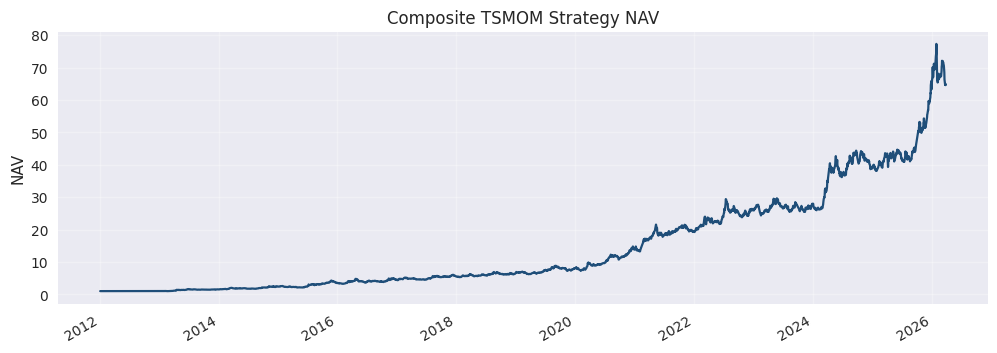

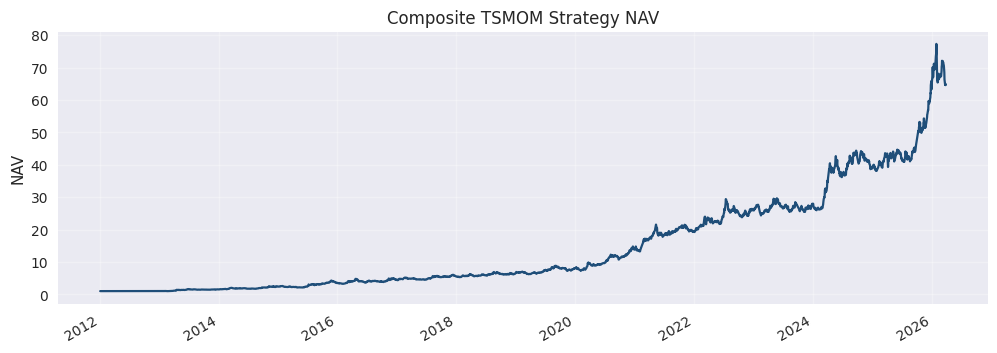

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
nav.plot(ax=ax, lw=1.6, color="#1f4e79")
ax.set_title("Composite TSMOM Strategy NAV")
ax.set_ylabel("NAV")
ax.grid(alpha=0.3)
plt.show()


## Step 5：板块研究与危机分析

这一步对应旧 `module4_analysis.py` 的研究思路。先用现有 `analysis` 模块跑最基础的板块和危机阶段结果，再决定后续是否补更细的 long/short asymmetry、动量持续性等分析。

In [14]:
symbol_to_sector = {
    sym: sector
    for sector, sector_syms in SECTOR_MAP.items()
    for sym in sector_syms
    if sym in returns_df.columns
}

sector_stats = sector_performance(returns_df, symbol_to_sector)
display(sector_stats)


""
sector
有色金属
黑色金属
能源化工


In [15]:
benchmark_symbol = "IF" if "IF" in returns_df.columns else returns_df.columns[0]
benchmark_returns = returns_df[benchmark_symbol].dropna()

crisis_stats = crisis_alpha_analysis(nav, benchmark_returns)
display(crisis_stats)


,strategy_return,benchmark_return,alpha
event,,,
2008全球金融危机,NaN,NaN,NaN
2015A股股灾,0.376193,-0.187423,0.563616
2016熔断,-0.022919,-0.007334,-0.015585
2018中美贸易战,0.162293,0.054787,0.107507
2020新冠疫情,0.175314,-0.064157,0.239471


## 研究结论与后续动作

建议在跑完第一版结果后，重点检查下面几项：
- `cta_lab` 的连续价格矩阵与旧 `module1_data.py` 生成结果是否同方向、同数量级
- `EqualRiskSizer` 输出权重与旧 `compute_position_weights` 的差异主要来自哪里
- 月度调仓、子策略收益等权合成，是否需要进一步向旧 `module3_backtest.py` 对齐
- `analysis` 层现有输出是否足够承接旧 `module4_analysis.py` 的研究内容

如果这份 notebook 跑通，下一步最自然的扩展是：
1. 补充月度再平衡版本回测
2. 对比单尺度 vs 三尺度 composite
3. 继续补 long/short asymmetry 与 momentum persistence
4. 最终把这条国内 CTA 工作流沉淀成 `cta_lab/strategies` 的正式实现
